# Assignment Code: DA-AG-018
Anomaly Detection & Time Series |
# Assignment

Question 1: What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.
>>
### **Short Answer – Anomaly Detection**

**Anomaly Detection** is the process of finding **unusual or abnormal data patterns** that do not match normal behavior. These unusual values are called **anomalies or outliers**. It is used in **fraud detection, security, healthcare, and fault detection**.

---

### **Types of Anomalies (Short)**

1. **Point Anomaly**
   A single data value that is very different from others.
   **Example:** Normal expense ₹1,000 → sudden expense ₹1,00,000.

2. **Contextual Anomaly**
   A value that is abnormal in a specific situation or time.
   **Example:** 30°C is normal in summer but abnormal in winter.

3. **Collective Anomaly**
   A group of data points that together form an anomaly.
   **Example:** Continuous high network traffic indicating a cyber attack.

---


Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.
>>
| Feature                       | **Isolation Forest (iForest)**                                          | **DBSCAN**                                                            | **Local Outlier Factor (LOF)**                                   |
| ----------------------------- | ----------------------------------------------------------------------- | --------------------------------------------------------------------- | ---------------------------------------------------------------- |
| **Approach**                  | Isolates anomalies using random splits; anomalies are easier to isolate | Density-based clustering; points in low-density regions are anomalies | Measures local density deviation of a point from its neighbors   |
| **Working Principle**         | Anomalies require fewer splits to separate                              | Points not belonging to any dense cluster are outliers                | Points with much lower local density than neighbors are outliers |
| **Type of Method**            | Tree-based, ensemble method                                             | Clustering-based method                                               | Distance & density-based method                                  |
| **Handles High Dimensions**   | Very good                                                               | Poor to moderate                                                      | Moderate                                                         |
| **Computational Efficiency**  | Fast and scalable                                                       | Slower for large datasets                                             | Slower for large datasets                                        |
| **Need for Parameter Tuning** | Low                                                                     | High (ε and minPts)                                                   | Moderate (k-neighbors)                                           |
| **Best Use Cases**            | Fraud detection, intrusion detection, large datasets                    | Spatial data, noise detection, clustering tasks                       | Detecting local anomalies in dense datasets                      |
| **Example Use Case**          | Credit card fraud detection                                             | Geographical data clustering, noise filtering                         | Detecting abnormal behavior in sensor data                       |


Question 3: What are the key components of a Time Series? Explain each with one
example.
>>
### **Answer: Key Components of a Time Series**

A **Time Series** is a sequence of data points collected **over time at regular intervals**.
Example: Daily temperature, monthly sales, yearly population, etc.

There are **four main components of a Time Series:**

---

### **1. Trend (T)**

The **long-term movement** or overall direction of the data (upward, downward, or constant).

**Example:**

* Yearly population increasing over time.
* Company sales growing every year.

---

### **2. Seasonal (S)**

Regular **repeating patterns** occurring within a fixed time period (daily, monthly, yearly).

**Example:**

* Ice cream sales increase every **summer**.
* Electricity usage increases during **evenings** daily.

---

### **3. Cyclical (C)**

Long-term **fluctuations that do not have a fixed period**, often influenced by economic or business cycles.

**Example:**

* Economic boom and recession cycles affecting business profits.
* Employment rate changes over several years.

---

### **4. Irregular / Random (I)**

**Unpredictable variations** caused by unexpected events.

**Example:**

* Sales drop due to **COVID-19 lockdown**.
* Stock market crash due to sudden political events.

---

### **Conclusion:**

Time Series = **Trend + Seasonal + Cyclical + Irregular**

---



Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?
>>
### **Answer: Stationarity in Time Series**

**Stationary Time Series** means a time series whose **statistical properties do not change over time**, i.e.:

* Mean is constant
* Variance is constant
* Covariance depends only on the lag, not on time

**Example:**
Daily random noise around a fixed average value.

---

### **How to Test Stationarity?**

1. **Visual Inspection (Plot Method)**

   * If mean and variance look constant → series is likely stationary.

2. **Rolling Statistics (Mean & Std Deviation)**

   * Plot rolling mean and rolling standard deviation.
   * If both are flat → stationary.

3. **Statistical Test – ADF Test (Augmented Dickey-Fuller Test)**

   * If **p-value < 0.05 → stationary**
   * If **p-value > 0.05 → non-stationary**

---

### **How to Transform Non-Stationary Series into Stationary?**

1. **Differencing**

   * Subtract previous value from current value.
   * Example: `y(t) - y(t-1)`

2. **Log Transformation**

   * Apply log to reduce variance.
   * Example: `log(y)`

3. **Seasonal Differencing**

   * Remove seasonal effects.
   * Example: `y(t) - y(t-12)`

4. **Detrending**

   * Remove trend using regression or moving average.

---

### **Conclusion**

Stationarity is essential for many time series models like **ARIMA**. If data is non-stationary, we apply **transformations like differencing and log scaling** to make it stationary.

---



Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.
>>
| Model                     | Full Form                                | Structure                  | Key Idea                               | Applications                            |
| ------------------------- | ---------------------------------------- | -------------------------- | -------------------------------------- | --------------------------------------- |
| **AR(p)**                 | AutoRegressive                           | Depends on past values     | Uses previous values to predict future | Stock prices, temperature, sales        |
| **MA(q)**                 | Moving Average                           | Depends on past errors     | Uses past forecast errors              | Noise smoothing, short-term forecasting |
| **ARIMA(p,d,q)**          | AutoRegressive Integrated Moving Average | AR + Differencing + MA     | Handles non-stationary time series     | Demand forecasting, finance             |
| **SARIMA(p,d,q)(P,D,Q)s** | Seasonal ARIMA                           | ARIMA + Seasonal terms     | Models seasonality                     | Monthly sales, weather data             |
| **SARIMAX**               | SARIMA with Exogenous variables          | SARIMA + external features | Uses external factors                  | Sales with ads, energy with weather     |


**
Dataset:
● NYC Taxi Fare Data
● AirPassengers Dataset
**

Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components
(Include your Python code and output in the code box below.)
>>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
#load datasets
df = pd.read_csv("AirPassengers.csv")

# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


df


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


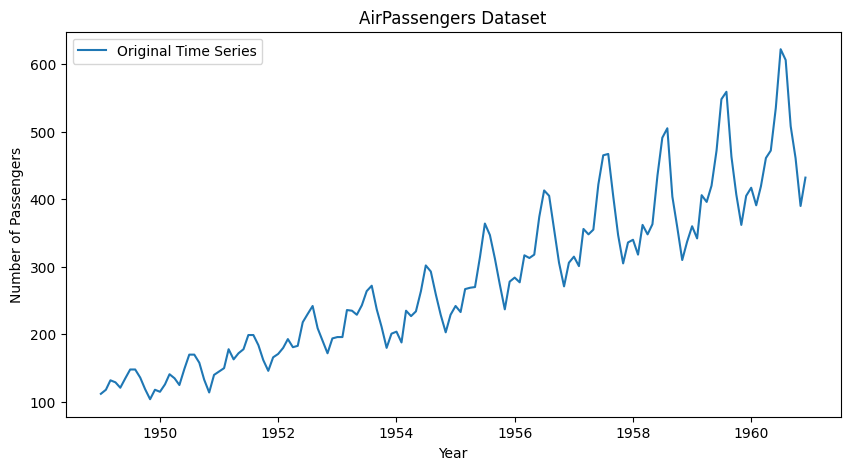

In [26]:
# Plot original time series
plt.figure(figsize=(10,5))
plt.plot(df, label='Original Time Series')
plt.title('AirPassengers Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

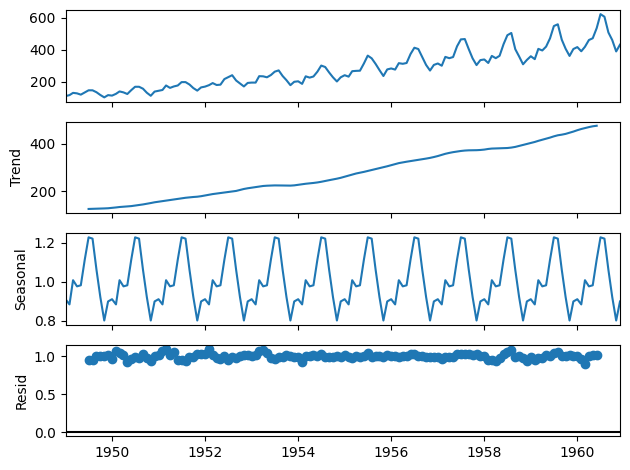

In [27]:
#decompose the series
decomposition = seasonal_decompose(df, model = 'multiplicative', period = 12)
# Plot decomposed components
decomposition.plot()
plt.show()

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.
(Include your Python code and output in the code box below.)


In [28]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


In [29]:
#load datasets
df = pd.read_csv("NYC_taxi_fare_data.csv")

/tmp/ipython-input-533375326.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("NYC_taxi_fare_data.csv")


In [30]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,1.0,N,238,239,1.0,6.00,3.00,0.5,1.47,0.00,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,1.0,N,239,238,1.0,7.00,3.00,0.5,1.50,0.00,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,1.0,N,238,238,1.0,6.00,3.00,0.5,1.00,0.00,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,1.0,N,238,151,1.0,5.50,0.50,0.5,1.36,0.00,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.00,1.0,N,193,193,2.0,3.50,0.50,0.5,0.00,0.00,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6405003,NaN,2020-01-31 22:51:00,2020-01-31 23:22:00,NaN,3.24,NaN,NaN,237,234,NaN,17.59,2.75,0.5,0.00,0.00,0.3,21.14,0.0
6405004,NaN,2020-01-31 22:10:00,2020-01-31 23:26:00,NaN,22.13,NaN,NaN,259,45,NaN,46.67,2.75,0.5,0.00,12.24,0.3,62.46,0.0
6405005,NaN,2020-01-31 22:50:07,2020-01-31 23:17:57,NaN,10.51,NaN,NaN,137,169,NaN,48.85,2.75,0.0,0.00,0.00,0.3,51.90,0.0
6405006,NaN,2020-01-31 22:25:53,2020-01-31 22:48:32,NaN,5.49,NaN,NaN,50,42,NaN,27.17,2.75,0.0,0.00,0.00,0.3,30.22,0.0


In [31]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

/tmp/ipython-input-2898973704.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("NYC_taxi_fare_data.csv")


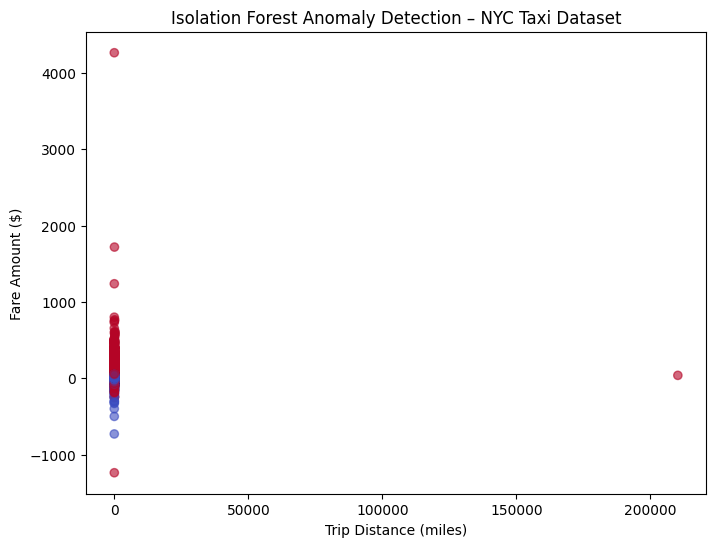

Total Anomalies Detected: 127982


,trip_distance,fare_amount,anomaly
69,14.52,41.0,1
223,15.69,44.0,1
419,23.47,61.5,1
646,0.00,39.2,1
687,22.80,66.5,1


In [24]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load dataset
# (Replace with your actual file path)
df = pd.read_csv("NYC_taxi_fare_data.csv")

# Select numerical features for anomaly detection
features = df[['trip_distance', 'fare_amount']]

# Drop missing values
features = features.dropna()

# Apply Isolation Forest
model = IsolationForest(contamination=0.02, random_state=42)
features['anomaly'] = model.fit_predict(features)

# Convert labels: 1 = Normal, -1 = Anomaly
features['anomaly'] = features['anomaly'].map({1: 0, -1: 1})

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(features['trip_distance'], features['fare_amount'],
            c=features['anomaly'], cmap='coolwarm', alpha=0.6)

plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Isolation Forest Anomaly Detection – NYC Taxi Dataset")
plt.show()

# Display detected anomalies
print("Total Anomalies Detected:", features['anomaly'].sum())
features[features['anomaly'] == 1].head()

Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.
(Include your Python code and output in the code box below.)
>>


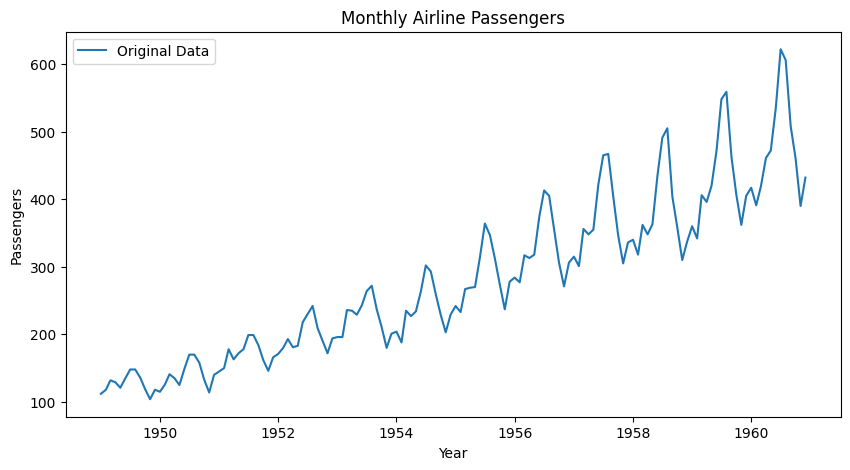

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


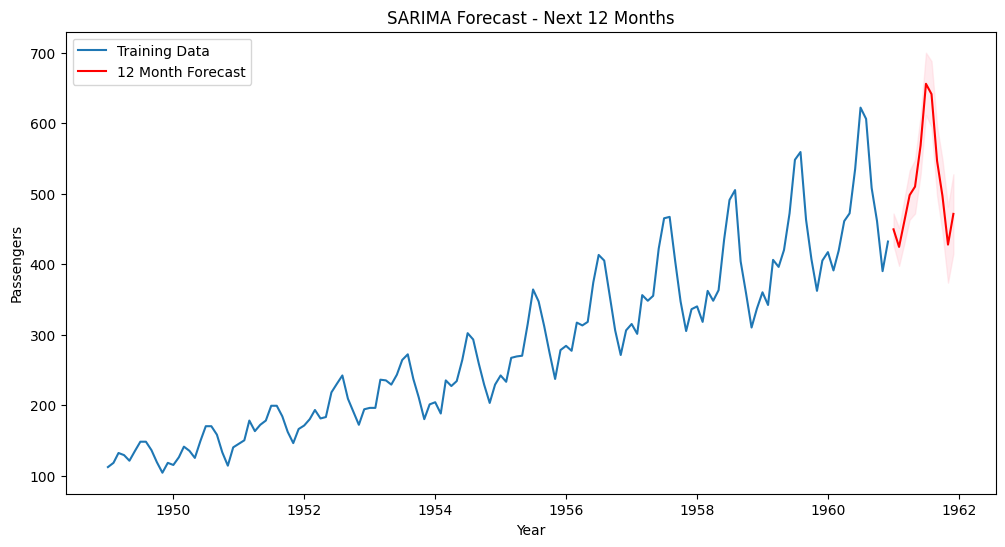

,Forecasted Passengers
1961-01-01,449.330269
1961-02-01,424.386564
1961-03-01,459.033907
1961-04-01,497.865803
1961-05-01,509.863877
1961-06-01,568.258851
1961-07-01,655.811113
1961-08-01,641.191479
1961-09-01,546.393734
1961-10-01,496.801909


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
# Dataset link: https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
#url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv('/content/AirPassengers.csv')

# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Plot original data
plt.figure(figsize=(10,5))
plt.plot(df, label="Original Data")
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Train SARIMA Model
model = SARIMAX(
    df['#Passengers'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

# Forecast next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create forecast index
forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='MS')

# Plot results
plt.figure(figsize=(12,6))
plt.plot(df, label='Training Data')
plt.plot(forecast_index, forecast_mean, color='red', label='12 Month Forecast')
plt.fill_between(forecast_index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.3)
plt.title("SARIMA Forecast - Next 12 Months")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Display forecast values
forecast_df = pd.DataFrame({
    'Forecasted Passengers': forecast_mean
}, index=forecast_index)

forecast_df

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.
(Include your Python code and output in the code box below.)
>>

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Generate synthetic numerical dataset
np.random.seed(42)
normal_data = 0.3 * np.random.randn(200, 2)
outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

X = np.vstack((normal_data, outliers))

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# Identify anomalies
anomalies = X[y_pred == -1]
normal = X[y_pred == 1]

# Plot results
plt.figure(figsize=(8,6))
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal Data')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomalies', marker='x')
plt.title("Anomaly Detection using Local Outlier Factor (LOF)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Print number of detected anomalies
print("Total points:", len(X))
print("Detected anomalies:", len(anomalies))

Question 10: You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:
● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
● How would you validate and monitor the performance over time?
● How would this solution help business decisions or operations?
(Include your Python code and output in the code box below.)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


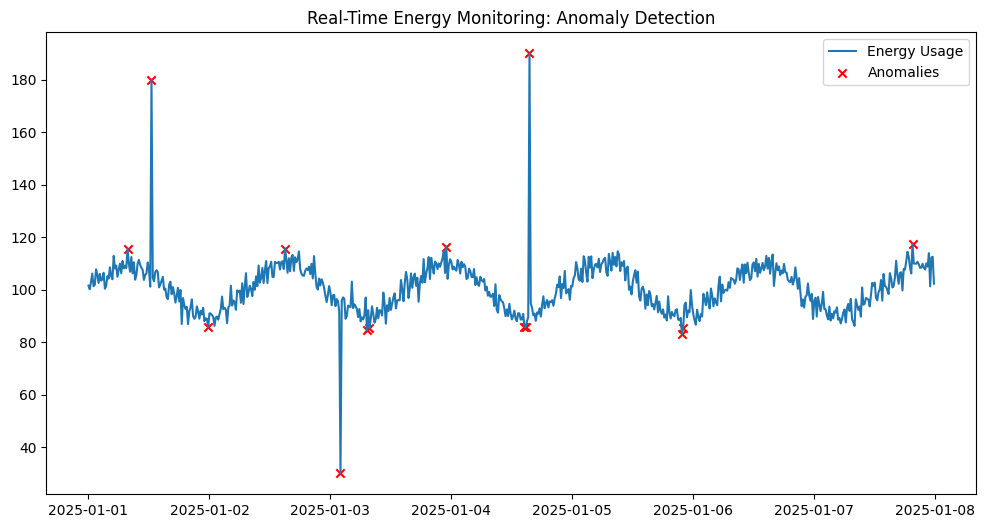

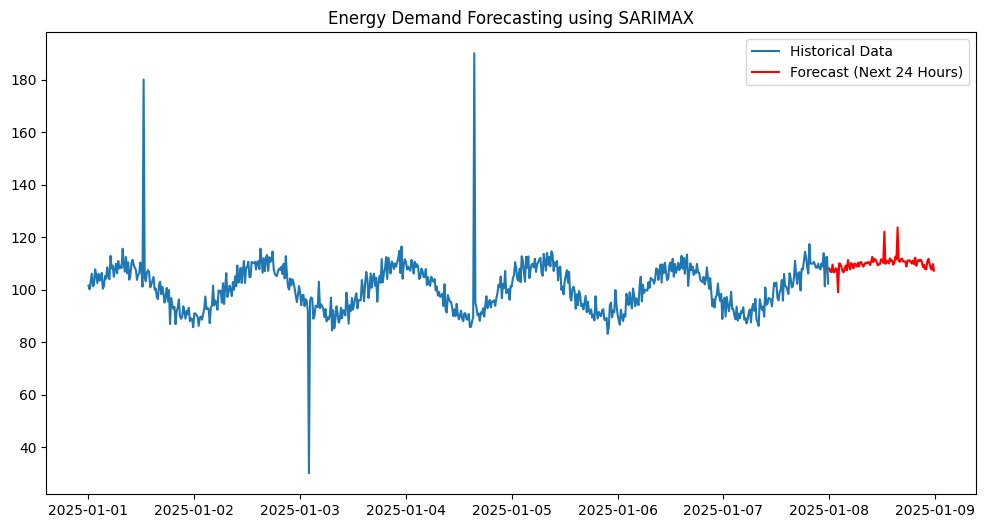

Total anomalies detected: 14


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Simulate 15-min interval data for 7 days
np.random.seed(42)
time_index = pd.date_range(start='2025-01-01', periods=7*24*4, freq='15min')

energy_usage = 100 + 10*np.sin(np.arange(len(time_index))/20) + np.random.normal(0, 3, len(time_index))

# Add artificial anomalies (spikes)
energy_usage[50] = 180
energy_usage[200] = 30
energy_usage[350] = 190

df = pd.DataFrame({'timestamp': time_index, 'energy_usage': energy_usage})
df.set_index('timestamp', inplace=True)

# ----------------- Anomaly Detection -----------------

iso = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = iso.fit_predict(df[['energy_usage']])

# ----------------- Forecasting -----------------

model = SARIMAX(df['energy_usage'], order=(1,1,1), seasonal_order=(1,1,1,96))
model_fit = model.fit(disp=False)

forecast = model_fit.get_forecast(steps=96)
forecast_mean = forecast.predicted_mean

# ----------------- Visualization -----------------

plt.figure(figsize=(12,6))
plt.plot(df.index, df['energy_usage'], label='Energy Usage')
plt.scatter(df[df['anomaly']==-1].index,
            df[df['anomaly']==-1]['energy_usage'],
            color='red', label='Anomalies', marker='x')
plt.title("Real-Time Energy Monitoring: Anomaly Detection")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df.index, df['energy_usage'], label='Historical Data')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecast (Next 24 Hours)')
plt.title("Energy Demand Forecasting using SARIMAX")
plt.legend()
plt.show()

print("Total anomalies detected:", len(df[df['anomaly']==-1]))